# Tokenization Techniques for LLMs


This notebook demonstrates various tokenization techniques used in Large Language Models (LLMs).
The following techniques are covered:

1. Character-Level Tokenization
2. Word-Level Tokenization
3. Subword-Level Tokenization:
    - Byte-Pair Encoding (BPE)
    - WordPiece Tokenization
    - SentencePiece Tokenization

### References

1. Sennrich, Rico, Haddow, Barry, and Birch, Alexandra. "Neural Machine Translation of Rare Words with Subword Units." 2016. arXiv preprint arXiv:1508.07909. [BPE]
2. Devlin, Jacob, Chang, Ming-Wei, Lee, Kenton, and Toutanova, Kristina. "BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding." 2019. arXiv preprint arXiv:1810.04805. [WordPiece]
3. Kudo, Taku. "Subword Regularization: Improving Neural Network Translation Models with Multiple Subword Candidates." 2018. arXiv preprint arXiv:1804.10959. [SentencePiece]

Each section contains a brief explanation and a Python implementation of the respective tokenization technique.


In [ ]:

# Character-Level Tokenization
def char_tokenize(text):
    return list(text)

text = "hello"
tokens = char_tokenize(text)
print("Character-Level Tokens:", tokens)


Character-Level Tokens: ['h', 'e', 'l', 'l', 'o']


In [ ]:

# Word-Level Tokenization
def word_tokenize(text):
    return text.split()

text = "I love AI"
tokens = word_tokenize(text)
print("Word-Level Tokens:", tokens)


Word-Level Tokens: ['I', 'love', 'AI']


### Byte-Pair Encoding (BPE) - Mathematical Basis

Byte-Pair Encoding (BPE) is a simple and effective subword tokenization technique. It was originally used for data compression but has been adapted for natural language processing, particularly in creating subword vocabularies for large language models.

#### Core Idea

BPE iteratively merges the most frequent pairs of symbols (characters or character sequences) into a single new symbol. The main idea is to build a vocabulary of subwords that represent the most common character sequences, allowing for the efficient representation of rare and unseen words.

#### Mathematical Explanation

Let the input text `T` be a sequence of characters. Initially, each character in the text is treated as a unique token. The goal is to merge the most frequent pair of consecutive tokens iteratively until a predefined vocabulary size is reached.

1. **Token Frequency Calculation**:
    - Suppose `T` is the input string.
    - The initial tokens are the characters of `T`.
    - Calculate the frequency of each consecutive pair of tokens. Mathematically, for any two consecutive tokens `(a, b)`, their frequency `f(a, b)` is the number of occurrences of the pair `(a, b)` in `T`.

2. **Merging the Most Frequent Pair**:
    - Identify the pair `(a, b)` with the highest frequency `f(a, b)` in the text.
    - Merge this pair into a new token `ab`.
    - Update the token sequence `T` by replacing all occurrences of the pair `(a, b)` with `ab`.

3. **Repeat**:
    - Continue the process of identifying and merging the most frequent token pairs until the desired vocabulary size is reached.

Let the vocabulary size be denoted as `V`. The algorithm continues until the number of unique tokens in the vocabulary reaches `V`.

Mathematically, the process can be described as iteratively optimizing the following objective:

$
    \text{argmax}_{(a,b)} \; f(a,b)
$

where `f(a,b)` is the frequency of the token pair `(a,b)` in the sequence. After finding the most frequent pair, the updated text sequence replaces all occurrences of `(a,b)` with the new token `ab`.

#### Example

Consider the input text `T = "ababab"`. The process would look like this:

1. Initial tokens: `['a', 'b', 'a', 'b', 'a', 'b']`
2. Pair frequencies: `(a,b): 3`
3. Merge `(a,b)` into `ab`: New tokens = `['ab', 'ab', 'ab']`

Continue this process until the desired vocabulary size is achieved.

#### Advantages of BPE

- **Handling OOV Words**: BPE helps mitigate the out-of-vocabulary (OOV) problem by breaking down rare words into subwords.
- **Efficiency**: By merging frequent pairs, BPE creates a compact and efficient representation of text.
  
This method is widely used in NLP, particularly for training models like GPT and BERT, where subword tokenization is essential for handling diverse vocabulary in a scalable way.


In [ ]:
from collections import defaultdict

def bpe_tokenize(text, vocab_size):
    # Initialize the vocabulary with individual characters
    vocab = set(text)
    vocab = {char: i for i, char in enumerate(vocab)}

    def get_pair_frequencies(text):
        pairs = defaultdict(int)
        for word in text:
            for i in range(len(word) - 1):
                pairs[(word[i], word[i + 1])] += 1
        return pairs

    text = list(text)  # Convert text to a list of characters
    while len(vocab) < vocab_size:
        pairs = get_pair_frequencies(text)
        if not pairs:
            break
        best_pair = max(pairs, key=pairs.get)
        new_token = ''.join(best_pair)
        vocab[new_token] = len(vocab)

        # Merge the most frequent pair
        i = 0
        while i < len(text) - 1:
            if text[i] == best_pair[0] and text[i + 1] == best_pair[1]:
                text[i] = new_token  # Replace the first element with the new token
                del text[i + 1]  # Remove the second element
            else:
                i += 1

    return text, vocab

text = "hello hello hell"
tokens, vocab = bpe_tokenize(text, 10)
print("BPE Tokens:", tokens)
print("BPE Vocabulary:", vocab)


BPE Tokens: ['h', 'e', 'l', 'l', 'o', ' ', 'h', 'e', 'l', 'l', 'o', ' ', 'h', 'e', 'l', 'l']
BPE Vocabulary: {'l': 0, ' ': 1, 'h': 2, 'e': 3, 'o': 4}


### WordPiece Tokenization - Mathematical Basis

WordPiece Tokenization is another subword tokenization technique commonly used in large language models, such as BERT. It was introduced to address the challenges of handling out-of-vocabulary (OOV) words while keeping the vocabulary size manageable.

#### Core Idea

The primary idea behind WordPiece tokenization is to break down words into smaller units, such as subwords or individual characters, in a way that maximizes the likelihood of the original word appearing in the corpus. It achieves this by iteratively building a vocabulary of subword units based on maximum likelihood estimation (MLE).

#### Mathematical Explanation

Let the input text `T` be a sequence of words. The goal of WordPiece tokenization is to find the subword units that maximize the likelihood of generating the input text from the vocabulary.

1. **Tokenization as Sequence Generation**:
   - Consider the word `w` from the input text `T`. The word `w` is represented as a sequence of subword tokens: $ w = t_1 t_2 \dots t_n $, where each `t_i` is a subword token from the vocabulary.
   - The probability of generating the word `w` from its subword tokens is given by:
     $
     P(w) = P(t_1, t_2, \dots, t_n)
     $
   - WordPiece tokenization aims to find the subword sequence that maximizes this probability.

2. **Maximum Likelihood Estimation (MLE)**:
   - For each word `w`, WordPiece tokenization selects the subword sequence that maximizes the likelihood of the word appearing in the corpus.
   - The probability of a word is modeled using MLE:
     $
     P(w) = \prod_{i=1}^{n} P(t_i | t_1, t_2, \dots, t_{i-1})
     $
   - The objective is to find the subword tokens that maximize this product of conditional probabilities.

3. **Greedy Search**:
   - WordPiece uses a greedy algorithm to build the subword sequence. Starting from the full word, it searches for the longest matching subword in the vocabulary.
   - If the entire word cannot be found in the vocabulary, the word is split into smaller subword units, down to individual characters if necessary.

4. **Vocabulary Building**:
   - The initial vocabulary consists of all individual characters in the training corpus.
   - During training, subwords are added to the vocabulary by merging the most frequent character sequences that maximize the likelihood of the text corpus.
   - The process continues until the desired vocabulary size is reached.

The optimization problem can be formally described as:

$
\text{argmax}_{t_1, t_2, \dots, t_n} \prod_{i=1}^{n} P(t_i | t_1, t_2, \dots, t_{i-1})
$

where `t_1, t_2, ..., t_n` are the subword tokens that compose the word `w`, and the goal is to maximize the likelihood of `w` given the context of the previous subwords.

#### Example

Consider the word `unhappiness`. WordPiece tokenization would attempt to split it into the longest subwords that maximize the likelihood. Suppose the vocabulary contains `un`, `##happy`, and `##ness`, where `##` indicates that a token is a suffix. The word `unhappiness` would be tokenized as `['un', '##happy', '##ness']`.

#### Advantages of WordPiece Tokenization

- **Efficiency**: WordPiece efficiently handles rare words by breaking them into smaller subword units.
- **Flexibility**: It balances between character-level and word-level tokenization, offering a middle ground where the most frequent words are represented as single tokens, and rare words are split into subwords.
  
WordPiece tokenization is widely used in transformer-based models, as it enables models to handle a large and diverse vocabulary with a fixed-size subword dictionary.


In [ ]:

# WordPiece Tokenization
def wordpiece_tokenize(text, vocab_size):
    vocab = set(text)
    vocab = {char: i for i, char in enumerate(vocab)}

    def get_best_pair(text, vocab):
        pairs = defaultdict(int)
        for word in text.split():
            for i in range(len(word) - 1):
                if word[i:i+2] not in vocab:
                    pairs[(word[i], word[i + 1])] += 1
        return max(pairs, key=pairs.get) if pairs else None

    while len(vocab) < vocab_size:
        best_pair = get_best_pair(text, vocab)
        if not best_pair:
            break
        new_token = ''.join(best_pair)
        vocab[new_token] = len(vocab)
        text = text.replace(''.join(best_pair), new_token)

    return text.split(), vocab

text = "hello hello hell"
tokens, vocab = wordpiece_tokenize(text, 10)
print("WordPiece Tokens:", tokens)
print("WordPiece Vocabulary:", vocab)


WordPiece Tokens: ['hello', 'hello', 'hell']
WordPiece Vocabulary: {'l': 0, ' ': 1, 'h': 2, 'e': 3, 'o': 4, 'he': 5, 'el': 6, 'll': 7, 'lo': 8}


### In-Depth Mathematical Basis of SentencePiece Tokenization

#### 1. **Subword Units and Tokenization**

The core idea of SentencePiece is to model text as a sequence of subword units. This involves defining a set of subwords such that they can effectively represent any word in the corpus. Mathematically, this is formulated as an optimization problem:

- **Objective**: Given a corpus $ C $ and a subword vocabulary $ V $, the goal is to segment each word $ w $ into a sequence of subword units $ \{s_1, s_2, \ldots, s_k\} $ such that the overall representation is efficient.

#### 2. **Byte Pair Encoding (BPE)**

BPE is a greedy algorithm for subword segmentation. It iterates over pairs of characters or subwords to find the most frequent pair and merges it into a new subword unit. Mathematically:

- **Pair Frequencies**: Let $ f(a, b) $ denote the frequency of the pair $ (a, b) $ in the corpus.

- **Merge Operation**: The most frequent pair $ (a, b) $ is merged to form a new subword unit $ c $, where:
  $
  c = a \cdot b
  $

- **Iteration**: This process is repeated until the vocabulary size reaches a specified limit $ V $.

#### 3. **Unigram Language Model**

The Unigram Language Model is used to optimize subword segmentation by maximizing the likelihood of the observed text. Let $ \{s_1, s_2, \ldots, s_k\} $ be a sequence of subwords and $ w $ be a word. The probability of $ w $ under the unigram model is given by:

- **Probability**:
  $
  P(w) = \prod_{i=1}^k P(s_i)
  $
  where $ P(s_i) $ is the probability of the subword unit $ s_i $.

- **Training**: The model estimates $ P(s_i) $ by counting the frequency of subwords in the corpus and normalizing:

  $
  P(s_i) = \frac{f(s_i)}{\sum_{j} f(s_j)}
  $

#### 4. **Optimization**

To find the optimal segmentation, SentencePiece minimizes the reconstruction loss, which is the negative log-likelihood of the observed text given the model. For a given word $ w $ segmented into $ \{s_1, s_2, \ldots, s_k\} $, the loss function is:

- **Loss Function**:
  $
  \text{Loss} = -\log P(w) = -\log \left(\prod_{i=1}^k P(s_i)\right) = -\sum_{i=1}^k \log P(s_i)
  $

- **Optimization Goal**: Minimize the average loss over all words in the corpus.

#### 5. **Mathematical Formulation of BPE in SentencePiece**

In SentencePiece, BPE can be formulated as follows:

- **Frequency Count**: Compute the frequency of each character pair in the training corpus.

- **Merge Operation**: Define a merge operation that combines the most frequent pair into a new subword unit.

- **Vocabulary Update**: Update the vocabulary with the new subword units and repeat the frequency counting and merge operations.

- **Stopping Criterion**: The process continues until the desired vocabulary size $ V $ is reached.

### References

1. Kudo, T., & Richardson, J. (2018). SentencePiece: A simple and language independent subword tokenizer and detokenizer. *arXiv preprint arXiv:1808.06226*.
2. Sennrich, R., Haddow, B., & Birch, A. (2016). Neural machine translation of rare words with subword units. *arXiv preprint arXiv:1508.07909*.


In [ ]:
!pip install numpy tensorflow==2.10.0 opencv-python scikit-learn

In [ ]:
from collections import defaultdict, Counter
import re

def get_stats(text):
    """Compute the frequency of adjacent character pairs in the text."""
    pairs = defaultdict(int)
    text = ' '.join(text)  # Join characters with spaces for easy pair handling
    symbols = text.split()
    for i in range(len(symbols) - 1):
        pairs[(symbols[i], symbols[i + 1])] += 1
    return pairs

def merge_vocab(pair, text):
    """Merge the most frequent pair in the text."""
    bigram = ' '.join(pair)
    replacement = ''.join(pair)
    pattern = re.compile(bigram)
    new_text = [pattern.sub(replacement, word) for word in text]
    return new_text

def sentencepiece_tokenize(text, vocab_size):
    """Tokenize the text using a simplified SentencePiece-like algorithm."""
    text = list(text)
    vocab = {char: i for i, char in enumerate(set(text))}
    vocab_size = min(vocab_size, len(vocab))

    while len(vocab) < vocab_size:
        pairs = get_stats(text)
        if not pairs:
            break
        best_pair = max(pairs, key=pairs.get)
        new_token = ''.join(best_pair)
        text = merge_vocab(best_pair, text)
        vocab[new_token] = len(vocab)

    return text, vocab

# Example usage
text = "hellohellohell"
tokens, vocab = sentencepiece_tokenize(text, 10)
print("SentencePiece Tokens:", tokens)
print("SentencePiece Vocabulary:", vocab)


SentencePiece Tokens: ['h', 'e', 'l', 'l', 'o', 'h', 'e', 'l', 'l', 'o', 'h', 'e', 'l', 'l']
SentencePiece Vocabulary: {'l': 0, 'o': 1, 'e': 2, 'h': 3}


# Image tokenization

### Patch-Based Tokenization

**Patch-Based Tokenization** involves dividing an image into smaller patches and treating each patch as a token. This approach is widely used in Vision Transformers (ViTs).

**Formula:**

For an image $ I $ of size $ H \times W \times C $ (Height $\times$ Width $\times$ Channels), and a patch size $ P_h \times P_w $, the number of patches $ N $ can be calculated as:

$ N = \left\lfloor \frac{H - P_h}{P_h} \right\rfloor \times \left\lfloor \frac{W - P_w}{P_w} \right\rfloor $

**Reference:**

- Dosovitskiy, A., Springenberg, J. T., & Riedmiller, M. (2014). Discriminative Unsupervised Feature Learning with Exemplar Convolutional Neural Networks. *IEEE Transactions on Pattern Analysis and Machine Intelligence (PAMI)*.


Saving KinectScreenshot-CoordinateMapping-05-22-09.bmp to KinectScreenshot-CoordinateMapping-05-22-09.bmp
Extracted 8040 patches of size 16x16.


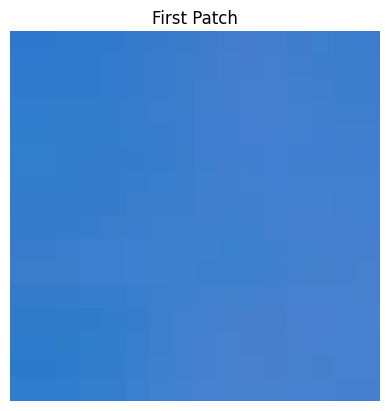

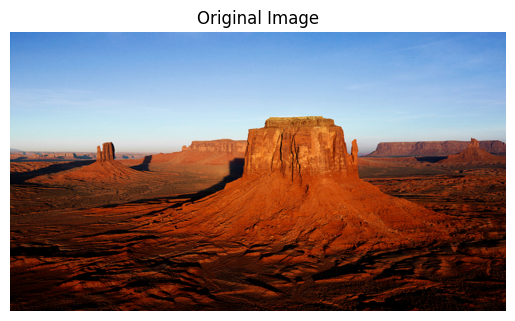

In [ ]:
import numpy as np
import cv2
from google.colab import files
import matplotlib.pyplot as plt

# Upload image file
uploaded = files.upload()

# Extract the filename from the uploaded files
filename = list(uploaded.keys())[0]

def extract_patches(image, patch_size):
    """Extract patches from an image."""
    patches = []
    height, width, _ = image.shape
    patch_height, patch_width = patch_size

    for y in range(0, height - patch_height + 1, patch_height):
        for x in range(0, width - patch_width + 1, patch_width):
            patch = image[y:y + patch_height, x:x + patch_width]
            patches.append(patch)

    return np.array(patches)

# Read the uploaded image
image = cv2.imread(filename)
# Convert the image from BGR to RGB for displaying
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Extract patches
patches = extract_patches(image, (16, 16))

# Print the number of patches and display the first patch
print(f"Extracted {len(patches)} patches of size 16x16.")

# Display the first patch (for example)
if len(patches) > 0:
    plt.imshow(cv2.cvtColor(patches[0], cv2.COLOR_BGR2RGB))
    plt.title("First Patch")
    plt.axis('off')
    plt.show()

# Optional: Display the original image
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('off')
plt.show()



### Feature-Based Tokenization

**Feature-Based Tokenization** involves using a pre-trained model to extract feature vectors from images, treating these features as tokens.

**Formula:**

For a feature extraction model $ f $ with weights $ \theta $, the feature vector $ \mathbf{v} $ for an image $ I $ can be expressed as:

$ \mathbf{v} = f(I; \theta) $

where $ f $ is a function representing the pre-trained model.

**Reference:**

- Simonyan, K., & Zisserman, A. (2014). Very Deep Convolutional Networks for Large-Scale Image Recognition. *arXiv preprint arXiv:1409.1556*.


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from google.colab import files

def extract_features(img_path):
    """Extract features from an image using a pre-trained VGG16 model."""
    model = VGG16(weights='imagenet', include_top=False, pooling='avg')
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    features = model.predict(x)
    return features.flatten()

# Upload image file
uploaded = files.upload()

# Extract the filename from the uploaded files
filename = list(uploaded.keys())[0]

# Example usage
features = extract_features(filename)
print(f"Extracted features shape: {features.shape}")



Saving IMG-20240608-WA0038.jpg to IMG-20240608-WA0038.jpg
1/1 [==============================] - 1s 844ms/step
Extracted features shape: (512,)


### Vector Quantization

**Vector Quantization** involves mapping continuous feature vectors to discrete tokens. This method uses clustering to create discrete codes.

**Formula:**

Given feature vectors $ \mathbf{x}_i $ and cluster centroids $ \mathbf{c}_k $, the quantized vector $ \hat{\mathbf{x}} $ is:

$ \hat{\mathbf{x}} = \arg\min_{k} \| \mathbf{x}_i - \mathbf{c}_k \|^2 $

where $ \| \cdot \|^2 $ denotes the squared Euclidean distance.

**Reference:**

- Gersho, A., & Gray, R. M. (1992). Vector Quantization and Signal Compression. *Kluwer Academic Publishers*.


In [ ]:
from sklearn.cluster import KMeans

def vector_quantization(features, num_clusters):
    """Apply vector quantization to features."""
    kmeans = KMeans(n_clusters=num_clusters, random_state=0)
    kmeans.fit(features)
    quantized_features = kmeans.predict(features)
    return quantized_features, kmeans

# Example usage
features = np.random.rand(1000, 64)  # Simulated features
quantized_features, kmeans = vector_quantization(features, num_clusters=10)
print(f"Quantized features shape: {quantized_features.shape}")


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Quantized features shape: (1000,)


### Autoencoders

**Autoencoders** are neural networks that learn to encode images into a lower-dimensional latent space, effectively tokenizing the image.

**Formula:**

For an autoencoder with encoder $ E $ and decoder $ D $, the encoding $ \mathbf{z} $ for an image $ I $ is:

$ \mathbf{z} = E(I; \theta_e) $

The reconstruction $ \hat{I} $ is:

$ \hat{I} = D(\mathbf{z}; \theta_d) $

where $ \theta_e $ and $ \theta_d $ are the parameters of the encoder and decoder, respectively.

**Reference:**

- Hinton, G. E., & Salakhutdinov, R. R. (2006). Reducing the Dimensionality of Data with Neural Networks. *Science*, 313(5786), 504-507.


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

def build_autoencoder(input_shape):
    """Build a simple autoencoder model."""
    input_img = Input(shape=input_shape)
    encoded = Dense(64, activation='relu')(input_img)
    decoded = Dense(np.prod(input_shape), activation='sigmoid')(encoded)
    autoencoder = Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
    return autoencoder

def train_autoencoder(x_train):
    """Train the autoencoder on the training data."""
    autoencoder = build_autoencoder(x_train.shape[1:])
    autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True)
    return autoencoder

# Example usage
x_train = np.random.rand(100, 784)  # Simulated training data
autoencoder = train_autoencoder(x_train)


Epoch 1/50
1/1 [==============================] - 1s 609ms/step - loss: 0.6978
Epoch 2/50
1/1 [==============================] - 0s 18ms/step - loss: 0.6946
Epoch 3/50
1/1 [==============================] - 0s 16ms/step - loss: 0.6934
Epoch 4/50
1/1 [==============================] - 0s 19ms/step - loss: 0.6930
Epoch 5/50
1/1 [==============================] - 0s 16ms/step - loss: 0.6929
Epoch 6/50
1/1 [==============================] - 0s 15ms/step - loss: 0.6928
Epoch 7/50
1/1 [==============================] - 0s 16ms/step - loss: 0.6928
Epoch 8/50
1/1 [==============================] - 0s 20ms/step - loss: 0.6927
Epoch 9/50
1/1 [==============================] - 0s 18ms/step - loss: 0.6926
Epoch 10/50
1/1 [==============================] - 0s 18ms/step - loss: 0.6925
Epoch 11/50
1/1 [==============================] - 0s 14ms/step - loss: 0.6923
Epoch 12/50
1/1 [==============================] - 0s 14ms/step - loss: 0.6922
Epoch 13/50
1/1 [==============================] - 0s 21ms/s

To generate a synthetic dataset of tokens for a large language model (LLM) in PyTorch, you can create a dataset consisting of sequences of tokens. Here’s a step-by-step guide to generate such a dataset:

Define Token Vocabulary: Create a vocabulary of tokens.
Generate Sequences: Create sequences of tokens from the vocabulary.
Create a Dataset: Use PyTorch’s Dataset class to format the data.
Below is an example of how to achieve this:

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

# Step 1: Define Token Vocabulary
class TokenVocabulary:
    def __init__(self, tokens):
        self.token_to_id = {token: i for i, token in enumerate(tokens)}
        self.id_to_token = {i: token for token, i in self.token_to_id.items()}
        self.size = len(tokens)

    def get_token_id(self, token):
        return self.token_to_id.get(token, self.token_to_id['<unk>'])

    def get_token(self, idx):
        return self.id_to_token.get(idx, '<unk>')

# Define a small vocabulary for the example
vocab_tokens = ['<pad>', '<unk>', 'hello', 'world', 'good', 'morning', 'night']
vocab = TokenVocabulary(vocab_tokens)

# Step 2: Generate Sequences
def generate_synthetic_sequences(num_sequences, sequence_length, vocab):
    sequences = []
    for _ in range(num_sequences):
        # Generate sequence using correct method call
        sequence = [vocab.get_token_id(np.random.choice(vocab_tokens)) for _ in range(sequence_length)]
        sequences.append(sequence)
    return sequences

# Parameters
num_sequences = 1000
sequence_length = 10

# Generate synthetic sequences
synthetic_sequences = generate_synthetic_sequences(num_sequences, sequence_length, vocab)

# Step 3: Create PyTorch Dataset
class SyntheticDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return torch.tensor(self.sequences[idx], dtype=torch.long)

# Create Dataset and DataLoader
dataset = SyntheticDataset(synthetic_sequences)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Example usage of the DataLoader
for batch in dataloader:
    print(batch)
    break


tensor([[0, 5, 3, 2, 0, 6, 3, 0, 0, 0],
        [3, 2, 0, 1, 2, 5, 1, 3, 2, 6],
        [4, 2, 5, 1, 2, 0, 3, 2, 6, 3],
        [5, 2, 5, 4, 6, 0, 4, 5, 3, 4],
        [3, 4, 0, 6, 6, 6, 2, 6, 0, 0],
        [3, 3, 3, 0, 3, 3, 3, 6, 3, 1],
        [0, 4, 6, 2, 0, 0, 5, 3, 0, 2],
        [4, 2, 3, 0, 0, 3, 6, 0, 6, 4],
        [6, 4, 4, 6, 4, 1, 6, 2, 6, 3],
        [6, 0, 1, 4, 6, 3, 2, 6, 0, 5],
        [0, 6, 2, 5, 1, 4, 2, 5, 1, 0],
        [6, 1, 3, 2, 4, 5, 5, 2, 3, 4],
        [2, 4, 0, 3, 4, 3, 5, 1, 3, 4],
        [4, 2, 6, 2, 1, 2, 1, 4, 3, 4],
        [3, 6, 4, 5, 5, 6, 1, 5, 1, 4],
        [5, 4, 1, 3, 5, 6, 2, 6, 3, 5],
        [2, 4, 6, 1, 1, 6, 2, 3, 6, 6],
        [6, 1, 4, 2, 5, 6, 4, 6, 6, 0],
        [2, 1, 2, 5, 6, 2, 4, 5, 0, 2],
        [2, 3, 5, 5, 4, 3, 3, 3, 5, 6],
        [0, 6, 5, 5, 5, 2, 3, 2, 0, 6],
        [0, 1, 1, 0, 1, 0, 6, 2, 0, 3],
        [4, 2, 6, 3, 1, 0, 6, 5, 2, 1],
        [1, 2, 2, 2, 2, 1, 6, 0, 2, 4],
        [4, 0, 6, 6, 3, 2, 1, 4, 5, 3],


### Explanation

**Define Token Vocabulary:**

- `TokenVocabulary` class maps tokens to IDs and vice versa.
- Define a small set of tokens for demonstration.

**Generate Sequences:**

- `generate_synthetic_sequences` function creates sequences of random tokens from the vocabulary.

**Create PyTorch Dataset:**

- `SyntheticDataset` class implements PyTorch’s `Dataset` to handle the synthetic sequences.
- Use `DataLoader` to batch and shuffle the dataset.

This code generates a synthetic dataset with sequences of tokens that can be used for training or evaluating language models. Adjust the vocabulary size, number of sequences, and sequence length based on your needs.


## **Techniques to Feed Combined Tokens from Images and Text**

Combining tokens from images and text is crucial in multimodal models, which are used in tasks like image captioning, visual question answering, and multimodal representation learning. Below are some common techniques to feed combined tokens from images and text into a model:

### 1. **Concatenation of Embeddings**
   - **Method**: Extract features (tokens) from the image and text separately, and concatenate their embeddings into a single input sequence.
   - **Steps**:
     1. **Image Tokenization**: Use a convolutional neural network (CNN) or a visual transformer (ViT) to extract visual tokens from the image (e.g., patches of the image).
     2. **Text Tokenization**: Tokenize the text using standard tokenization techniques like BPE, WordPiece, or SentencePiece.
     3. **Concatenation**: Concatenate the visual tokens with the text tokens to create a single sequence.
     4. **Feed to Model**: Feed the combined sequence into a multimodal model, such as a transformer, for further processing.

   - **Example**: In vision-language models, the output from the last hidden layer of a pre-trained ResNet model might be used as visual tokens and concatenated with text tokens from a transformer-based language model like BERT  .

### 2. **Cross-Attention Mechanisms**
   - **Method**: Use cross-attention mechanisms to allow interactions between image and text tokens within the model.
   - **Steps**:
     1. **Image and Text Embeddings**: Extract embeddings separately for the image and text.
     2. **Attention Layers**: Introduce cross-attention layers, where the query comes from one modality (e.g., text) and the key/value pairs come from the other modality (e.g., image).
     3. **Feed to Model**: Pass the combined representation through subsequent transformer layers to allow multimodal reasoning.

   - **Example**: In multimodal transformers, text tokens might attend to image features (and vice versa) through cross-attention layers, enabling the model to learn dependencies between the two modalities .

### 3. **Bilinear Pooling**
   - **Method**: Combine image and text representations using bilinear pooling, which captures interactions between all pairs of image and text features.
   - **Steps**:
     1. **Image Features**: Extract features from the image using a CNN or a transformer.
     2. **Text Features**: Extract features from the text using a language model.
     3. **Bilinear Pooling**: Apply bilinear pooling (e.g., Multimodal Compact Bilinear Pooling or MCB) to combine the image and text features.
     4. **Feed to Model**: Use the pooled representation as input to a downstream task, such as classification or captioning.

   - **Example**: In visual question answering (VQA), bilinear pooling can combine image features and question embeddings to create a joint representation that is fed into a classifier to predict the answer .

### 4. **Fusion Layers**
   - **Method**: Introduce dedicated fusion layers to integrate image and text tokens. These layers learn how to combine information from both modalities.
   - **Steps**:
     1. **Separate Encoders**: Use separate encoders for images and text (e.g., a CNN for images and a transformer for text).
     2. **Fusion Layer**: Introduce a fusion layer, such as a fully connected layer or a transformer-based fusion layer, to combine the image and text representations.
     3. **Feed to Model**: Pass the combined output through the rest of the model for further processing.

   - **Example**: In image captioning models, fusion layers can combine visual features from an image encoder and text embeddings from a language model to generate captions .

### 5. **Co-Attention Mechanisms**
   - **Method**: Use co-attention mechanisms to allow simultaneous interactions between image and text tokens.
   - **Steps**:
     1. **Image and Text Embeddings**: Extract embeddings for both modalities.
     2. **Co-Attention Layers**: Implement co-attention layers, where both the image and text tokens attend to each other.
     3. **Feed to Model**: Use the resulting joint representation as input to subsequent layers of the model.

   - **Example**: In visual question answering, co-attention layers allow both image and question embeddings to interact directly, helping the model focus on relevant parts of the image when answering questions .

### 6. **Multimodal Transformers**
   - **Method**: Use a transformer architecture specifically designed to handle multiple modalities, such as the Vision-and-Language Transformer (ViLT) or VisualBERT.
   - **Steps**:
     1. **Unified Tokenization**: Convert both image patches and text tokens into a unified token representation.
     2. **Transformer Layers**: Use shared transformer layers to process both image and text tokens simultaneously.
     3. **Feed to Model**: Use the output of the transformer layers for downstream tasks.

   - **Example**: In multimodal transformer models, image patches and text tokens are processed in a unified manner to generate a joint representation, as seen in models like ViLT and VisualBERT .

### 7. **Graph-Based Approaches**
   - **Method**: Represent both image and text data as nodes in a graph, and use graph neural networks (GNNs) to capture relationships between them.
   - **Steps**:
     1. **Graph Construction**: Represent image regions and text tokens as nodes in a graph, and create edges based on relationships between them (e.g., spatial relationships for image regions and semantic relationships for text tokens).
     2. **Graph Processing**: Use GNNs to propagate information across the graph and generate a joint representation of the image and text.
     3. **Feed to Model**: Use the graph's output as input to a downstream task.

   - **Example**: In visual relationship detection, a graph-based model might represent objects in the image and text descriptions as nodes, with edges representing relationships between them, to predict object relationships .

### References
1. Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*. NAACL-HLT.
2. Dosovitskiy, A., et al. (2021). *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale*. ICLR.
3. Vaswani, A., et al. (2017). *Attention is All You Need*. NeurIPS.
4. Fukui, A., et al. (2016). *Multimodal Compact Bilinear Pooling for Visual Question Answering and Visual Grounding*. EMNLP.
5. Vinyals, O., Toshev, A., Bengio, S., & Erhan, D. (2015). *Show and Tell: A Neural Image Caption Generator*. CVPR.
6. Lu, J., et al. (2016). *Hierarchical Question-Image Co-Attention for Visual Question Answering*. NeurIPS.
7. Kim, W., Son, B., & Kim, I. (2021). *ViLT: Vision-and-Language Transformer Without Convolution or Region Supervision*. ICML.
8. Kipf, T. N., & Welling, M. (2017). *Semi-Supervised Classification with Graph Convolutional Networks*. ICLR.


In [ ]:
# Concatenation of Embeddings
import torch
import torch.nn as nn

# Example image and text embeddings
image_embedding = torch.randn(1, 512)  # Image embedding (e.g., from a CNN)
text_embedding = torch.randn(1, 768)   # Text embedding (e.g., from a transformer)

# Concatenation of embeddings
combined_embedding = torch.cat((image_embedding, text_embedding), dim=-1)
print("Combined Embedding Shape:", combined_embedding.shape)

# Example model processing the concatenated embedding
model = nn.Linear(combined_embedding.shape[-1], 100)
output = model(combined_embedding)
print("Model Output Shape:", output.shape)


Combined Embedding Shape: torch.Size([1, 1280])
Model Output Shape: torch.Size([1, 100])


In [ ]:
# Cross-Attention Mechanisms
import torch
import torch.nn as nn

class CrossAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super(CrossAttention, self).__init__()
        self.multihead_attn = nn.MultiheadAttention(embed_dim, num_heads)

    def forward(self, query, key, value):
        # Transpose the inputs to (sequence_length, batch_size, embed_dim)
        query = query.transpose(0, 1)
        key = key.transpose(0, 1)
        value = value.transpose(0, 1)

        attn_output, _ = self.multihead_attn(query, key, value)

        # Transpose the output back to (batch_size, sequence_length, embed_dim)
        return attn_output.transpose(0, 1)

# Example embeddings (batch_size, sequence_length, embedding_dim)
image_tokens = torch.randn(8, 10, 512)  # Image tokens
text_tokens = torch.randn(8, 15, 512)   # Text tokens

# Cross-attention: text attending to image tokens
cross_attn = CrossAttention(embed_dim=512, num_heads=8)
attn_output = cross_attn(text_tokens, image_tokens, image_tokens)
print("Cross-Attention Output Shape:", attn_output.shape)


Cross-Attention Output Shape: torch.Size([8, 15, 512])


In [ ]:
# Bilinear Pooling
import torch
import torch.nn.functional as F

# Example features
image_features = torch.randn(8, 512)  # Image features
text_features = torch.randn(8, 768)   # Text features

# Bilinear pooling: element-wise multiplication followed by summing across the batch
bilinear_pooled = torch.bmm(image_features.unsqueeze(2), text_features.unsqueeze(1)).view(8, -1)
print("Bilinear Pooled Shape:", bilinear_pooled.shape)

# Example model
model = nn.Linear(bilinear_pooled.shape[-1], 100)
output = model(bilinear_pooled)


Bilinear Pooled Shape: torch.Size([8, 393216])


In [ ]:
# Fusion Layers
import torch
import torch.nn as nn

# Example features
image_features = torch.randn(8, 512)  # Image features
text_features = torch.randn(8, 768)   # Text features

# Fusion layer (fully connected layer)
fusion_layer = nn.Linear(512 + 768, 1024)
combined_features = torch.cat((image_features, text_features), dim=-1)
fused_output = fusion_layer(combined_features)
print("Fused Output Shape:", fused_output.shape)


Fused Output Shape: torch.Size([8, 1024])


In [ ]:
# Co-Attention Mechanisms
import torch
import torch.nn as nn

class CoAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super(CoAttention, self).__init__()
        self.text_to_image_attn = nn.MultiheadAttention(embed_dim, num_heads)
        self.image_to_text_attn = nn.MultiheadAttention(embed_dim, num_heads)

    def forward(self, text_tokens, image_tokens):
        # Transpose input tensors to (sequence_length, batch_size, embed_dim)
        text_tokens_t = text_tokens.transpose(0, 1)
        image_tokens_t = image_tokens.transpose(0, 1)

        # Text attending to image tokens
        text_attn, _ = self.text_to_image_attn(text_tokens_t, image_tokens_t, image_tokens_t)

        # Image attending to text tokens
        image_attn, _ = self.image_to_text_attn(image_tokens_t, text_tokens_t, text_tokens_t)

        # Transpose the output back to (batch_size, sequence_length, embed_dim)
        text_attn = text_attn.transpose(0, 1)
        image_attn = image_attn.transpose(0, 1)

        return text_attn, image_attn

# Example tokens
image_tokens = torch.randn(8, 10, 512)  # Image tokens
text_tokens = torch.randn(8, 15, 512)   # Text tokens

# Co-attention mechanism
co_attention = CoAttention(embed_dim=512, num_heads=8)
text_attn, image_attn = co_attention(text_tokens, image_tokens)
print("Text Attention Output Shape:", text_attn.shape)
print("Image Attention Output Shape:", image_attn.shape)


Text Attention Output Shape: torch.Size([8, 15, 512])
Image Attention Output Shape: torch.Size([8, 10, 512])


In [ ]:
# Multimodal Transformers
import torch
import torch.nn as nn

class MultimodalTransformer(nn.Module):
    def __init__(self, embed_dim, num_heads, num_layers):
        super(MultimodalTransformer, self).__init__()
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, combined_tokens):
        # Apply the transformer encoder
        return self.transformer_encoder(combined_tokens)

# Example tokens
image_tokens = torch.randn(10, 8, 512)  # (seq_len, batch_size, embedding_dim)
text_tokens = torch.randn(15, 8, 512)

# Combine image and text tokens
combined_tokens = torch.cat((image_tokens, text_tokens), dim=0)
print("Combined Tokens Shape:", combined_tokens.shape)

# Multimodal transformer
multimodal_transformer = MultimodalTransformer(embed_dim=512, num_heads=8, num_layers=6)
output = multimodal_transformer(combined_tokens)
print("Multimodal Transformer Output Shape:", output.shape)


Combined Tokens Shape: torch.Size([25, 8, 512])
Multimodal Transformer Output Shape: torch.Size([25, 8, 512])
